<a href="https://colab.research.google.com/github/di-claro-batera/faculdade_data_science/blob/main/Atividade_SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from google.colab import files

plt.rcParams['figure.figsize'] = [15,10]

In [2]:
url = 'https://raw.githubusercontent.com/higoramario/univesp-com410-aprendizado-de-maquinas/main/rice-classification.csv'
arroz = pd.read_csv(url, sep=',')
arroz.head()

,id,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,1,4537,92.229316,64.012769,0.719916,4677,76.004525,0.657536,273.085,0.764510,1.440796,1
1,2,2872,74.691881,51.400454,0.725553,3015,60.471018,0.713009,208.317,0.831658,1.453137,1
2,3,3048,76.293164,52.043491,0.731211,3132,62.296341,0.759153,210.012,0.868434,1.465950,1
3,4,3073,77.033628,51.928487,0.738639,3157,62.551300,0.783529,210.657,0.870203,1.483456,1
4,5,3693,85.124785,56.374021,0.749282,3802,68.571668,0.769375,230.332,0.874743,1.510000,1


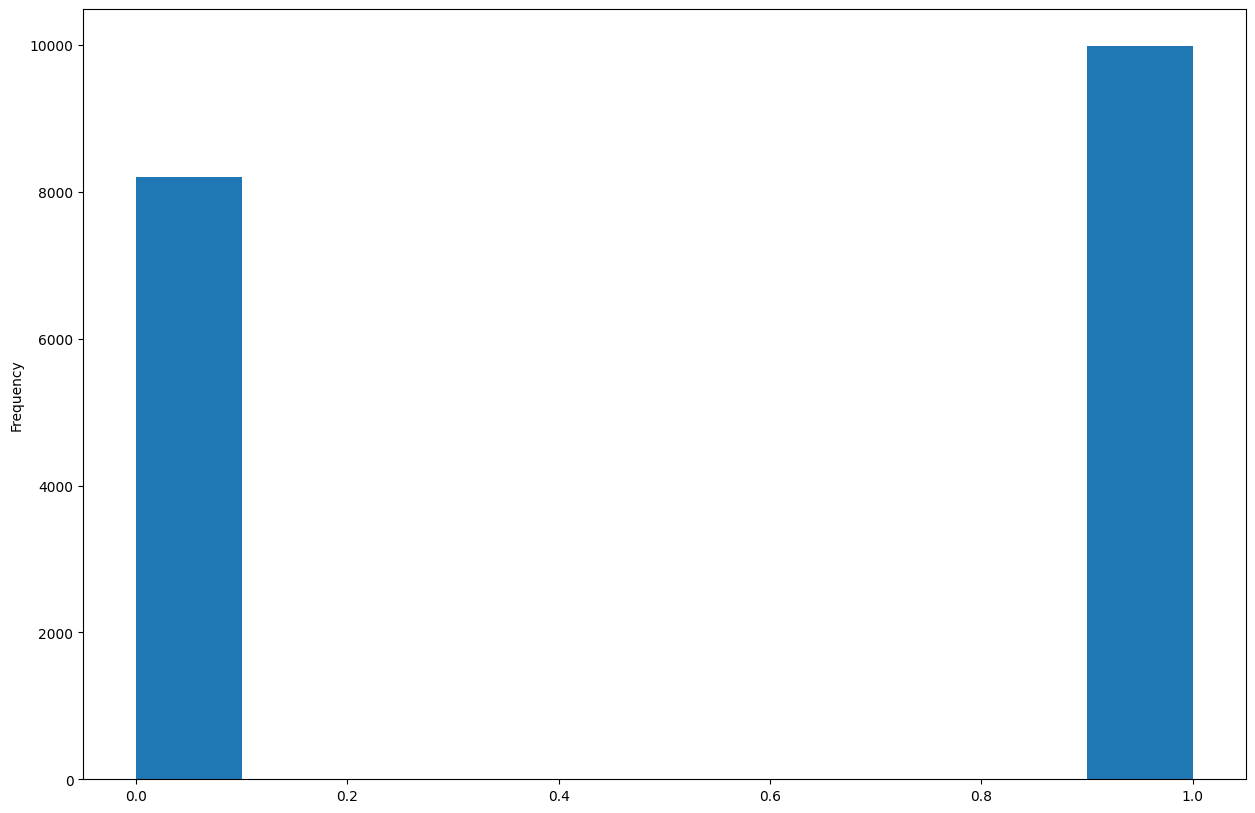

In [3]:
arroz['Class'].plot.hist()
plt.show()

In [5]:
atributos_todos = arroz[['Area','MajorAxisLength','MinorAxisLength','Eccentricity','ConvexArea','EquivDiameter','Extent','Perimeter','Roundness','AspectRation']]
classes = arroz['Class']

In [6]:
arroz_treino_todos, arroz_teste_todos, classes_treino_todos, classes_teste_todos = train_test_split(atributos_todos, classes, test_size=0.1)

In [7]:
scaler = StandardScaler()
arroz_treino_todos = scaler.fit_transform(arroz_treino_todos)
arroz_teste_todos = scaler.transform(arroz_teste_todos)

In [9]:
SVM_polinomial_todos = SVC(kernel='poly', degree=3, C=1.0, coef0=2)
SVM_polinomial_todos.fit(arroz_treino_todos, classes_treino_todos)

SVC(coef0=2, kernel='poly')

In [10]:
predicao_todos = SVM_polinomial_todos.predict(arroz_teste_todos)
acuracia_todos = accuracy_score(classes_teste_todos, predicao_todos)
print('Acurácia de classificação com todos os atributos: {}'.format(round(acuracia_todos,3)*100)+'%')

Acurácia de classificação com todos os atributos: 98.9%


In [11]:
atributos = arroz[['Area','MajorAxisLength']]
classes = arroz['Class']

In [12]:
arroz_treino, arroz_teste, classes_treino, classes_teste = train_test_split(atributos, classes, test_size=0.1)

In [13]:
scaler = StandardScaler()
arroz_treino = scaler.fit_transform(arroz_treino)
arroz_teste = scaler.transform(arroz_teste)

In [14]:
SVM_linear = SVC(kernel='linear', C=0.2)
SVM_linear.fit(arroz_treino, classes_treino)

SVC(C=0.2, kernel='linear')

In [16]:
predicao_linear = SVM_linear.predict(arroz_teste)
acuracia_linear = accuracy_score(classes_teste, predicao_linear)
print('Acurácia de classificação da SVM linear com dois atributos: {}'.format(round(acuracia_linear,3)*100)+'%')

Acurácia de classificação da SVM linear com dois atributos: 98.5%


In [19]:
#funcao que recebe os atributos e classes do conjunto de testes, o classificador SVM e plota os resultados

def visualizarSVM(atributos_t, classes_t, classificador):
  atributos, classes = atributos_t, classes_t
  ano, salario= np.meshgrid(np.arange(start=atributos[:,0].min()-1, stop=atributos[:,0].max()+1, step=0.01),
  np.arange(start=atributos[:,1].min()-1, stop=atributos[:,1].max()+1, step=0.01))

  plt.contourf(ano, salario, classificador.predict(np.array([ano.ravel(), salario.ravel()]).T).reshape(ano.shape),
  alpha=0.75, cmap=ListedColormap(('red','green')))

  plt.xlim(ano.min(), ano.max())
  plt.ylim(salario.min(), salario.max())

  for i, j in enumerate(np.unique(classes)):
    plt.scatter(atributos[classes==j,0], atributos[classes==j,1],
    color=ListedColormap(('red','green'))(i), label=j)

  plt.title('Classificação com SVM')
  plt.xlabel('Ano')
  plt.ylabel('Salário estimado')
  plt.legend()
  plt.show()


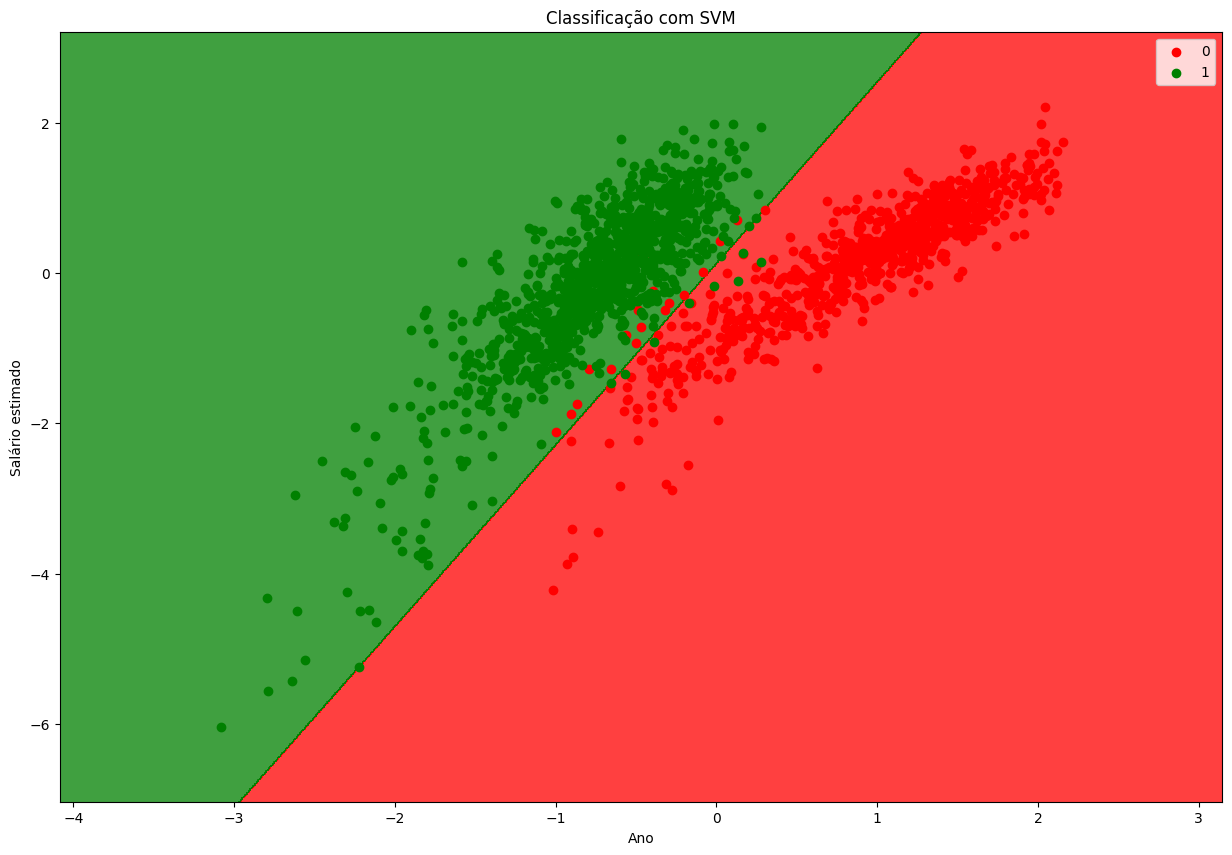

In [20]:
visualizarSVM(arroz_teste, classes_teste, SVM_linear)

In [21]:
SVM_polinomial = SVC(kernel='poly', degree=3, C=1.0, coef0=2)
SVM_polinomial.fit(arroz_treino, classes_treino)

SVC(coef0=2, kernel='poly')

In [22]:
predicao_poli = SVM_polinomial.predict(arroz_teste)
acuracia_poli = accuracy_score(classes_teste, predicao_poli)
print('Acurácia de classificação da SVM polinomial com dois atributos: {}'.format(round(acuracia_poli,3)*100)+'%')

Acurácia de classificação da SVM polinomial com dois atributos: 98.5%


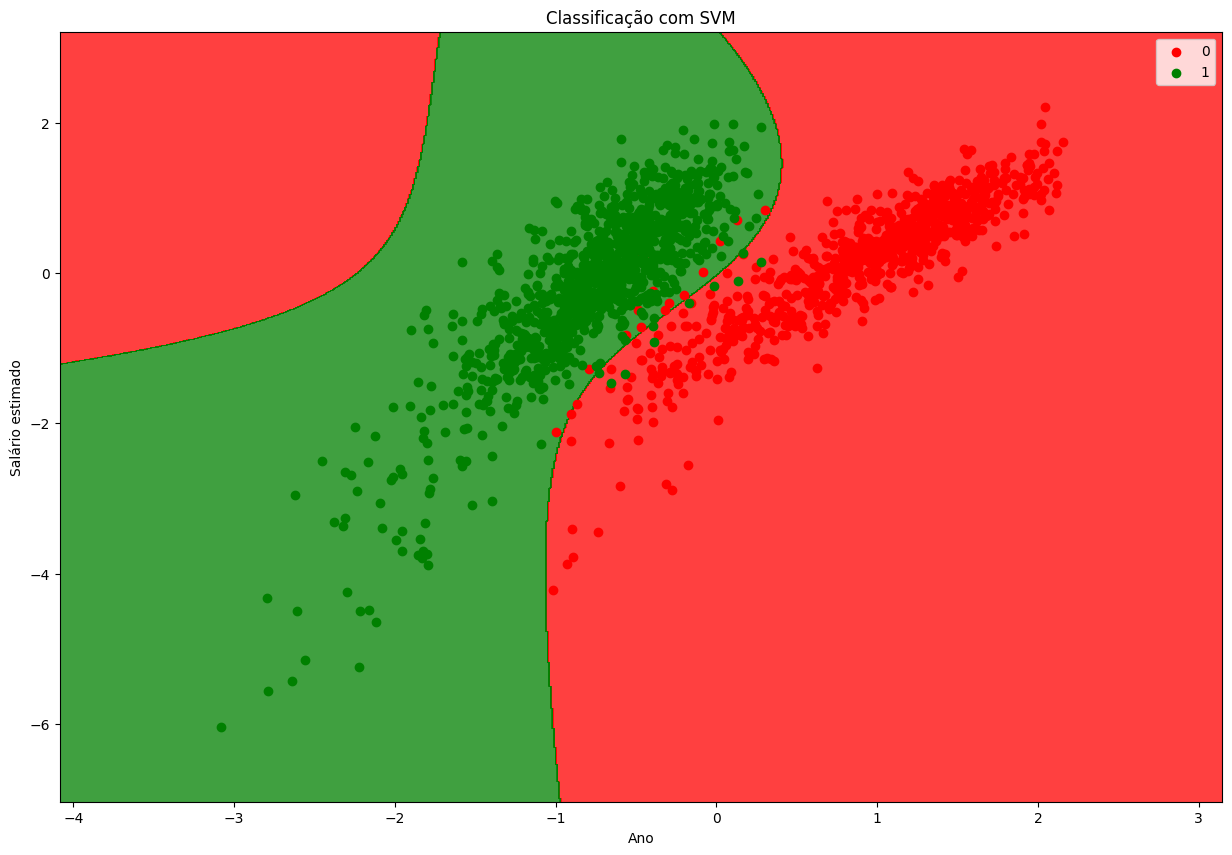

In [23]:
visualizarSVM(arroz_teste, classes_teste, SVM_polinomial)

In [24]:
SVM_sigmoidal = SVC(kernel='sigmoid', gamma='scale', C=2, coef0=2)
SVM_sigmoidal.fit(arroz_treino, classes_treino)

SVC(C=2, coef0=2, kernel='sigmoid')

In [25]:
predicao_sigmoidal = SVM_sigmoidal.predict(arroz_teste)
acuracia_sigmoidal = accuracy_score(classes_teste, predicao_sigmoidal)
print('Acurácia de classificação da SVM sigmoidal com dois atributos: {}'.format(round(acuracia_sigmoidal,3)*100)+'%')

Acurácia de classificação da SVM sigmoidal com dois atributos: 73.5%


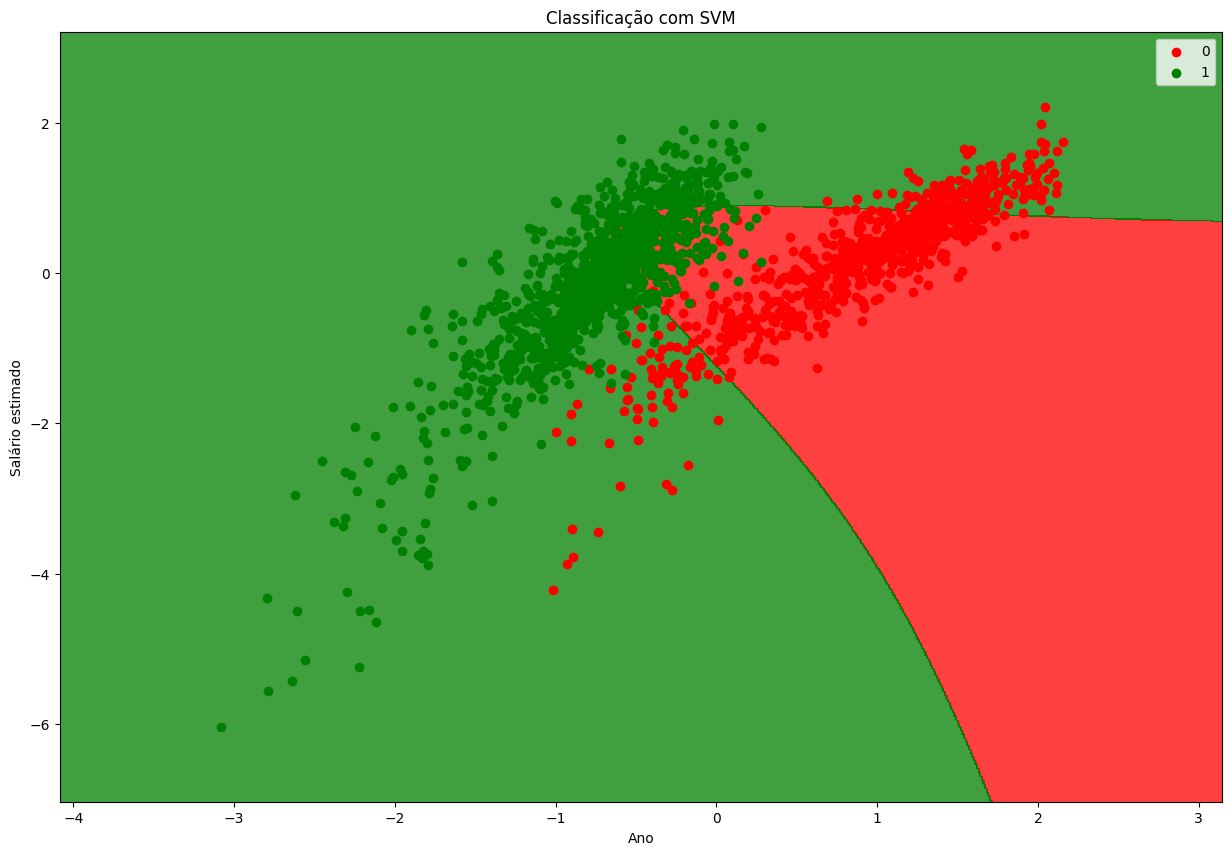

In [26]:
visualizarSVM(arroz_teste, classes_teste, SVM_sigmoidal)